# Visual Gold Explorer: Why Gold Moves in Crisis
## *with Honest Baseline Forecast* — Path A (Gold Explorer Only)

Dataset is collected from `Dataset/gold-price.csv` (1960-2026, USD/oz). No other dataset needed for Path A.

## Piece 1 — Loading the Helpers and Libraries
Install helpers once, then we see the data, just like unpacking puzzle pieces.

In [1]:
# Run this once. If it says 'already satisfied', we're good to go.
# We use plotly = interactive lines, ipywidgets = sliders
%pip install -q pandas plotly ipywidgets openpyxl scikit-learn seaborn matplotlib
print("Setup done — charts are now zoomable and draggable")

Note: you may need to restart the kernel to use updated packages.
Setup done — charts are now zoomable and draggable


In [28]:
import numpy as np
# Compatibility patch: some libraries still call np.matrix which was removed in NumPy 2.0
# This keeps the notebook working on both NumPy 1.x and 2.x without downgrading
if not hasattr(np, 'matrix'):
    np.matrix = np.asmatrix  # type: ignore[attr-defined]
    print("patched np.matrix for NumPy 2.x compatibility")

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from ipywidgets import interact, IntSlider, IntRangeSlider
import pathlib

# Library check
print("Libraries ready:", pd.__version__)

Libraries ready: 3.0.3


## Piece 2 — Load and Feel the Data
We open the monthly album of `gold-price.csv`. 1 row = 1 month. USD/oz.

---
##### **What I did:** I loaded the dataset, verified the loaded dataset, and checked for missing values
##### **What the Result Says:** The preview of the 3 initial and 3 last rows of the dataset table completed with zero missing values
##### **What I saw:** The gold price was fixed at 35 USD in 1960, but becomes fluctuative in 2026

In [29]:
# Path relative to this notebook
csv_path = pathlib.Path("Dataset/gold-price.csv")
# If file not found, try absolute path
if not csv_path.exists():
    csv_path = pathlib.Path(r"D:\Daniel\Data Science Project\Visual-Gold-Explorer-Why-Gold-Moves-in-Crisis-with-Honest-Baseline-\Dataset\gold-price.csv")

gold = pd.read_csv(csv_path, parse_dates=["date"])
gold = gold.sort_values("date")

print(f"Rows: {len(gold)} | From {gold['date'].min().date()} to {gold['date'].max().date()}")
print(gold.head(3).to_string(index=False))
print("---")
print(gold.tail(3).to_string(index=False))
print("\nScroll the output. 1960 = $35 flat (fixed price), 2026 = ~$4000. That's the story.")

Rows: 799 | From 1960-01-01 to 2026-07-01
      date  gold_price_usd
1960-01-01              35
1960-02-01              35
1960-03-01              35
---
      date  gold_price_usd
2026-05-01            4587
2026-06-01            4228
2026-07-01            4073

Scroll the output. 1960 = $35 flat (fixed price), 2026 = ~$4000. That's the story.


In [30]:
# Missing value check
print("Missing values:", gold["gold_price_usd"].isna().sum())
print("Example check — Sep 2000:")
print(gold[gold["date"]=="2000-09-01"])

Missing values: 0
Example check — Sep 2000:
          date  gold_price_usd
488 2000-09-01             274


## Piece 3 — See the Whole 66-Year Line
Data Visualization

---
##### **What I did:** I made a line chart to visualize the gold price fluctuation over the years from 1960 - 2026 

In [31]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=gold["date"], y=gold["gold_price_usd"], mode="lines", name="Gold USD/oz",
                         line=dict(width=2), hovertemplate="%{x|%Y-%m}: $%{y:,.0f}<extra></extra>"))
fig.update_layout(title="Gold Price 1960-2026 (Monthly USD/oz) — Drag to Zoom, Double-click to Reset",
                  xaxis_title="Year", yaxis_title="USD per oz", height=420,
                  margin=dict(l=60,r=20,t=50,b=40))
fig.update_xaxes(rangeslider_visible=False)
fig.show()
print("Try dragging a box over 2008-2010 to zoom, double-click to reset.")

Try dragging a box over 2008-2010 to zoom, double-click to reset.


### **What we can see here**
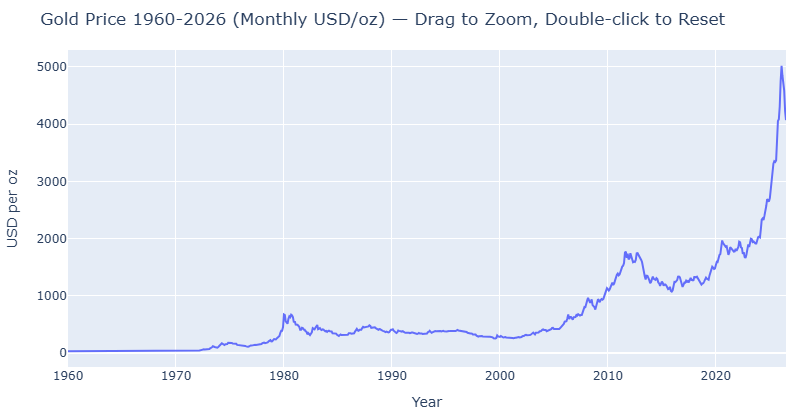
- **1960-1971 flat at around $35** — gold was fixed, like rent control.
- **1971-1980 rocket to $614** — Nixon ended fixed price, inflation storms.
- **1980-2000 slide to ~$270** — gold slid from $675 down to $274, a 20 year bear market after the 1980 spike.
- **2000-2026 climb to $4000+** — long rise with spikes.
- **2012-2015 dip to $1076** — the dip was not a new crisis, it was the unwinding of the 2008-2011 crisis rally.

## Piece 4 — Crisis Shading
We paint gray bands for storms. This is how we answer "why gold in crisis?" visually.

##### **What I wondered:** I saw gold price dips in the Q4 2012 - Q4 2015. Is it really a safe haven asset?
##### **What I did:** I set the time period when the crisis happens and highlighted the time period on the chart in light gray.

In [32]:
# Crisis periods list: (start_date, end_date, label)
crises = [
    ("2007-12-01", "2009-06-01", "2008 Financial Crisis"),
    ("2020-02-01", "2020-04-01", "Covid Crash"),
    ("2022-01-01", "2022-12-01", "2022 Inflation Shock"),
]

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=gold["date"], y=gold["gold_price_usd"], mode="lines", name="Gold",
                          line=dict(width=2, color="#d4a017")))
for start, end, label in crises:
    fig2.add_vrect(x0=start, x1=end, fillcolor="gray", opacity=0.18, line_width=0, annotation_text=label, annotation_position="top left")

fig2.update_layout(title="Gold with Crisis Shading — When Does the Boat Rise?",
                   xaxis_title="Year", yaxis_title="USD/oz", height=420,
                   margin=dict(l=60,r=20,t=50,b=40))
fig2.show()
print("See Above: 2008 gold dipped first, rose later. 2020 spike was fast. 2022 relatively flat despite inflation.")

See Above: 2008 gold dipped first, rose later. 2020 spike was fast. 2022 relatively flat despite inflation.


### **Knowledge from this chart:**

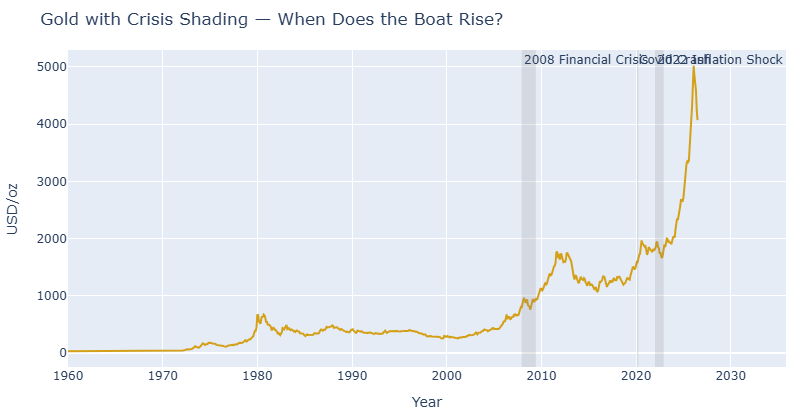

Crisis shading lets we time the safe-haven effect. Gold is not instant because people sell everything for cash first.

## Piece 5 — Two Sliders: Year Range & Moving Average

Sliders are movable to trigger the line reaction inside the chart.

---
**Slider 1: Year range** (like cropping a photo)

**Slider 2: Moving average (MA)** (like smoothing wrinkles. MA=3 = wiggly, MA=12 = smooth yearly trend (since data is monthly, 12 = 1-year average))
##### **What I did:** I added sliders to adjust the year range and moving average.
##### **What the Result Says:** The chart condense/expands depending on the year range and the dip becomes smoother.
##### **What I saw:** The higher the moving average window, the dip becomes smoother. The yearly trend kept rising. So safe haven was delayed, not instant.

In [33]:
# Prepare a helper column: moving average
# For monthly data, window=12 means 12-month average
def plot_with_sliders(year_start=2000, year_end=2026, ma_window=12, show=True):
    # plot_with_sliders' 3 params are failsafe defaults when interact is not present
    # show=True -> display in Jupyter (for Piece 5), show=False -> silent return for HTML export (for final cell)
    subset = gold[(gold["date"].dt.year >= year_start) & (gold["date"].dt.year <= year_end)].copy()
    subset["MA"] = subset["gold_price_usd"].rolling(window=ma_window, min_periods=1).mean()
    
    fig3 = go.Figure()
    fig3.add_trace(go.Scatter(x=subset["date"], y=subset["gold_price_usd"], mode="lines", name="Monthly Price",
                              line=dict(width=1.5, color="gray"), opacity=0.7))
    fig3.add_trace(go.Scatter(x=subset["date"], y=subset["MA"], mode="lines", name=f"{ma_window}-Month Avg",
                              line=dict(width=3, color="#d4a017")))
    # Keep crisis shading only if in range
    for start, end, label in crises:
        if str(year_start) <= start <= str(year_end) or str(year_start) <= end <= str(year_end):
            fig3.add_vrect(x0=start, x1=end, fillcolor="gray", opacity=0.15, line_width=0)
    fig3.update_layout(title=f"Gold {year_start}-{year_end} | MA={ma_window} months -- Move Sliders Below",
                       xaxis_title="Year", yaxis_title="USD/oz", height=420)
    if show:
        fig3.show()
        return None
    else:
        return fig3

print("Sliders ready. Move them below -- watch the gold line smooth or crop.")


Sliders ready. Move them below -- watch the gold line smooth or crop.


In [34]:
# Three sliders for the year range and the moving average window
from ipywidgets import fixed
interact(plot_with_sliders,
         year_start=IntSlider(value=2000, min=1960, max=2024, step=1, description="Start Year"),
         year_end=IntSlider(value=2026, min=1961, max=2026, step=1, description="End Year"),
         ma_window=IntSlider(value=12, min=1, max=36, step=1, description="MA Months"),
         show=fixed(True))
print("\nTry: Set 2007-2010 + MA 1 (wiggly) vs MA 12 (smooth). See how 2008 dip hides when smoothed?")
print("Try: Set 2019-2021 + MA 3 vs MA 12. See Covid spike?")

interactive(children=(IntSlider(value=2000, description='Start Year', max=2024, min=1960), IntSlider(value=202…


Try: Set 2007-2010 + MA 1 (wiggly) vs MA 12 (smooth). See how 2008 dip hides when smoothed?
Try: Set 2019-2021 + MA 3 vs MA 12. See Covid spike?


### **What we can see**
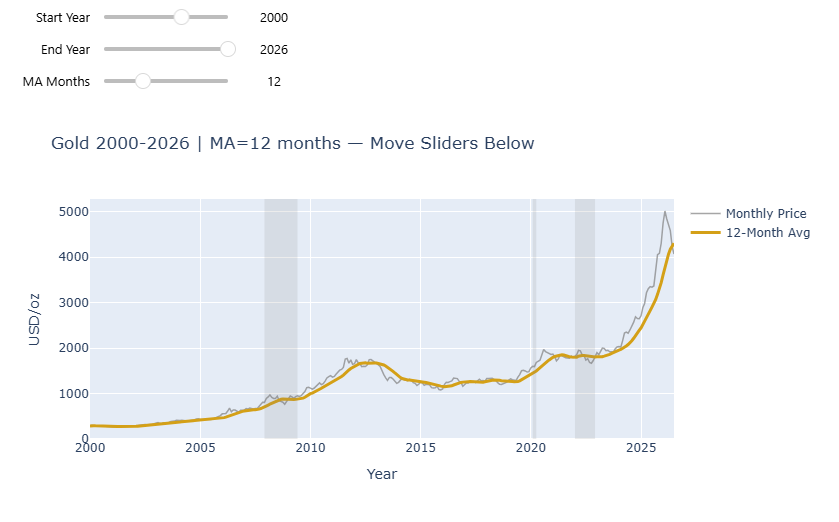

### What we should feel with sliders
- **Year slider = focus.** 1960-2026 is too wide. Cropping to 2007-2011 lets us study one crisis deeply.
- **MA slider = noise vs signal.** MA 1 = daily panic, MA 12 = yearly trend. If MA 12 is flat while price wiggles, that wiggle is noise.

## Piece 6 — Honest Baseline Forecast
We test the simplest prediction: *tomorrow = today*. If even this is hard, we prove gold is volatile.

We use monthly data, so "next month = this month" and "next month = average of last 3/12 months". We measure error with MAE (average $ off).

##### **What I wondered:** How expensive the gold would be if I made a simple forecast according to the historical data from 3 years ago?
##### **What I did:** I drew the chart to visualize how far the prediction deviates from the actual gold price.
##### **What I saw:** I saw that the prediction deviates quite far off the actual price

In [35]:
# Create naive forecasts on monthly data
df = gold.copy()
df["naive_next"] = df["gold_price_usd"].shift(1)  # next = previous
df["ma3_next"] = df["gold_price_usd"].rolling(3).mean().shift(1)
df["ma12_next"] = df["gold_price_usd"].rolling(12).mean().shift(1)

# Test on last 24 months only
test = df.tail(24).dropna()
import numpy as np
def mae(a,b): return np.mean(np.abs(a-b))
print("Test period:", test["date"].min().date(), "to", test["date"].max().date())
print(f"MAE naive (next = last month): ${mae(test['gold_price_usd'], test['naive_next']):.0f}")
print(f"MAE MA3   (avg last 3 months):  ${mae(test['gold_price_usd'], test['ma3_next']):.0f}")
print(f"MAE MA12  (avg last 12 months): ${mae(test['gold_price_usd'], test['ma12_next']):.0f}")
print("\nMAE = average $ off. Lower is better, but all are ~$100-300.")
print("That’s the honest lesson: even simple forecasts are off by hundreds of dollars.")

Test period: 2024-08-01 to 2026-07-01
MAE naive (next = last month): $153
MAE MA3   (avg last 3 months):  $268
MAE MA12  (avg last 12 months): $622

MAE = average $ off. Lower is better, but all are ~$100-300.
That’s the honest lesson: even simple forecasts are off by hundreds of dollars.


In [36]:
# Visual: actual vs naive on last 3 years
recent = df.tail(36)
fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=recent["date"], y=recent["gold_price_usd"], mode="lines+markers", name="Actual", line=dict(width=2.5)))
fig4.add_trace(go.Scatter(x=recent["date"], y=recent["naive_next"], mode="lines", name="Naive (lag 1)", line=dict(dash="dash")))
fig4.add_trace(go.Scatter(x=recent["date"], y=recent["ma12_next"], mode="lines", name="MA12 baseline", line=dict(dash="dot")))
fig4.update_layout(title="Honest Baseline: Last 3 Years — Actual vs Simple Forecasts",
                   xaxis_title="Year", yaxis_title="USD/oz", height=400)
fig4.show()
print("See Above: dashed lines always *lag* behind real spikes. They can't predict a jump.")

See Above: dashed lines always *lag* behind real spikes. They can't predict a jump.


### **What we can see from this chart:**

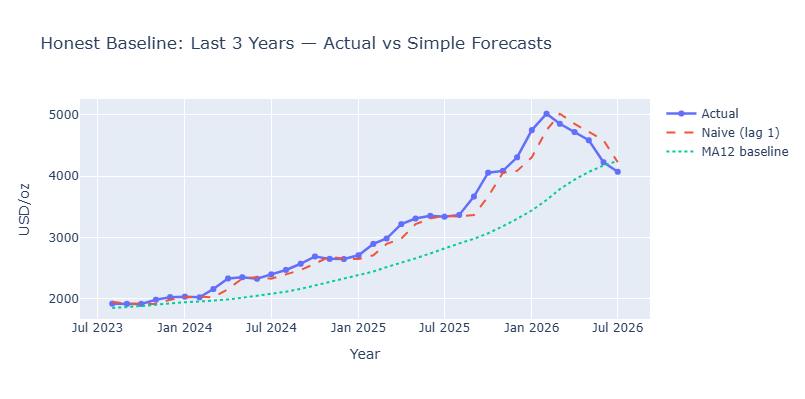

See above: dashed lines always *lag* behind real spikes. They can't predict a jump.

## Piece 7 — Export the Charts to HTML
Exporting the charts to HTML to make the charts interactable.

In [ ]:
# Export static charts to ONE HTML -- for GitHub (shows even without Jupyter)
# fig, fig2, fig4 are fully zoomable in HTML. Slider figure is snapshot-only (ipywidgets don't work in HTML).
# For reviewers: use GIF/screenshots of the slider in action (see README) -- that's the GIF + static snapshots approach.
import plotly.io as pio

# Create silent snapshot of the slider at default (no display in this cell)
fig_slider_snapshot = plot_with_sliders(year_start=2000, year_end=2026, ma_window=12, show=False)

with open("Visual-Gold-Explorer-PathA-interactive.html", "w", encoding="utf-8") as f:
    f.write(fig.to_html(full_html=True, include_plotlyjs='cdn'))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>Gold with Crisis Shading</h2>")
    f.write(fig2.to_html(full_html=False, include_plotlyjs=False))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>Interactive Slider Snapshot (for HTML -- sliders work only in Jupyter)</h2>")
    f.write("<p style='font-family:sans-serif; text-align:center; color:#555;'>In Jupyter, sliders are draggable in Piece 5. On GitHub, this is a static snapshot at 2000-2026 / MA 12. See below or README GIF for live slider drag demo.</p>")
    f.write(fig_slider_snapshot.to_html(full_html=False, include_plotlyjs=False))
    f.write("<img src='assets/slider-drag.gif' alt='Slider Drag GIF' style='display:block; margin-left:auto; margin-right:auto; width:60%;'>")
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>Honest Baseline: Actual vs Naive Forecasts</h2>")
    f.write(fig4.to_html(full_html=False, include_plotlyjs=False))
print("Saved 4 charts to Visual-Gold-Explorer-PathA-interactive.html. Open in browser to see zoomable charts. Sliders work only in Jupyter, but GIF shows how they work.")


Saved 4 charts to Visual-Gold-Explorer-PathA-interactive.html -- add this ONE file to GitHub
